# Heston × QuantLib calibration comparison

This notebook compares **calibration behavior**, not just pricing.

It uses the same temporary deterministic Heston-ready quote universe as the QuantLib pricing cross-check, then runs:

1. this library's Heston calibration;
2. QuantLib's `HestonModelHelper` calibration;
3. price/error comparison on the same selected quote universe;
4. parameter and diagnostic comparison.

Important interpretation:

- This is **qualitative**, not an exact equality test.
- Your calibration and QuantLib calibration do not optimize exactly the same objective.
- Different parameters with similar residual scale can be normal.
- The useful question is whether QuantLib shows the same broad stress pattern: high vol-of-vol, weak Feller, high kappa, or residual concentration.


In [1]:
from __future__ import annotations

import json
import os
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path(os.environ.get(
    "OPL_PROJECT_ROOT",
    r"C:\Users\ouwez\Documents\Quant\option-pricing-library",
)).expanduser()

DATA_ROOT = Path(os.environ.get("OPL_DATA_ROOT", str(PROJECT_ROOT / "data"))).expanduser()
MODEL_VALIDATION_ROOT = DATA_ROOT / "gold" / "model_validation_bundle"

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

UNDERLYINGS = ["SPY", "QQQ", "IWM", "MSFT", "NVDA", "TSLA"]
EXCLUDE_BUNDLES = {("SPY", "2026-06-03")}

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 260)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MODEL_VALIDATION_ROOT:", MODEL_VALIDATION_ROOT)


PROJECT_ROOT: C:\Users\ouwez\Documents\Quant\option-pricing-library
MODEL_VALIDATION_ROOT: C:\Users\ouwez\Documents\Quant\option-pricing-library\data\gold\model_validation_bundle


In [2]:
from option_pricing.diagnostics.heston import (
    heston_calibration_fit_summary,
    run_heston_calibration_fit_diagnostics,
)
from option_pricing.marketdata.gold import (
    heston_quote_set_from_frame,
    market_data_snapshot_from_json,
)
from option_pricing.models.heston import HestonParams
from option_pricing.models.heston.calibration import (
    HestonCalibrationBounds,
    calibrate_heston_multistart,
    preflight_heston_quotes,
)
from option_pricing.numerics.quadrature import QuadratureConfig
from option_pricing.pricers.heston import heston_price_from_ctx
from option_pricing.types import OptionType

try:
    import QuantLib as ql
    QUANTLIB_AVAILABLE = True
    print("QuantLib available:", getattr(ql, "__version__", "unknown version"))
except Exception as exc:
    ql = None
    QUANTLIB_AVAILABLE = False
    print("QuantLib unavailable:", type(exc).__name__, exc)


QuantLib available: 1.41


In [3]:
# This library calibration.
OWN_OBJECTIVE_TYPE = "price_rmse"
MAX_SEEDS = 8
MAX_NFEV = 300
USE_ANALYTIC_JAC = True

# Pricing settings for evaluating both calibrated models on the same selected quotes.
ROBUST_QUAD_CFG = QuadratureConfig(u_max=260.0, n_panels=56, nodes_per_panel=32)
QL_ENGINE_ORDER = 192
ROUND_LIBRARY_TAU_TO_QL_DAYS = True

# Temporary deterministic Heston-ready universe filter.
MIN_QUOTES = 80
MIN_EXPIRIES = 3
MIN_QUOTES_PER_RIGHT = 20
MIN_EXPIRY_DAYS = 7.0
MAX_EXPIRY_DAYS = 180.0
MAX_ABS_LOG_MONEYNESS = 0.35
MAX_RELATIVE_SPREAD = 0.35
MAX_QUOTES_TOTAL = 900
MAX_QUOTES_PER_EXPIRY_RIGHT = 80

# QuantLib calibration helper settings.
# This is qualitative: QuantLib helper calibration is not the same objective as OWN_OBJECTIVE_TYPE.
QL_MAX_HELPERS_PER_UNDERLYING = 120
QL_MAX_ITERATIONS = 800
QL_END_CRITERIA_STATIONARY_FUNCTION_VALUE_ITERATIONS = 100
QL_MONEYNESS_TARGETS = np.array([-0.30, -0.20, -0.10, -0.05, 0.0, 0.05, 0.10, 0.20, 0.30])
QL_START_FROM_OWN_FIT = True


## Load saved bundles and prepare a deterministic Heston-ready universe

This is a temporary workaround until the library exposes a plug-and-play bundle → model-ready workflow.


In [4]:
@dataclass(frozen=True)
class Bundle:
    root: Path
    underlying: str
    date: str
    run_id: str


def _part(path: Path, name: str) -> str:
    prefix = f"{name}="
    for p in path.parts:
        if p.startswith(prefix):
            return p.split("=", 1)[1]
    return ""


bundle_paths = sorted(
    p for p in MODEL_VALIDATION_ROOT.glob("underlying=*/date=*/run_id=*")
    if (p / "market_data.json").exists()
    and (p / "heston_quotes.parquet").exists()
    and (p / "manifest.json").exists()
)

bundles = []
for p in bundle_paths:
    underlying = _part(p, "underlying")
    date = _part(p, "date")
    run_id = _part(p, "run_id")
    if UNDERLYINGS and underlying not in UNDERLYINGS:
        continue
    if (underlying, date) in EXCLUDE_BUNDLES:
        continue
    bundles.append(Bundle(root=p, underlying=underlying, date=date, run_id=run_id))

print(f"bundles found: {len(bundles)}")
for b in bundles:
    print(b.underlying, b.date, b.run_id)


bundles found: 6
IWM 2026-06-06 b4a-20260606T111054Z-d64ab9a6
MSFT 2026-06-06 b4a-20260606T111126Z-0d4d8cc7
NVDA 2026-06-06 b4a-20260606T111142Z-82961440
QQQ 2026-06-06 b4a-20260606T111029Z-2c8a4d1d
SPY 2026-06-06 b4a-20260606T111002Z-a037b8fe
TSLA 2026-06-06 b4a-20260606T111158Z-a2346800


In [5]:
def load_bundle(bundle: Bundle) -> dict[str, Any]:
    market_payload = json.loads((bundle.root / "market_data.json").read_text(encoding="utf-8"))
    market_snapshot = market_data_snapshot_from_json(market_payload)
    heston_quotes = pd.read_parquet(bundle.root / "heston_quotes.parquet")
    return {
        "market_payload": market_payload,
        "market_snapshot": market_snapshot,
        "market_data": market_snapshot.market_data,
        "heston_quotes": heston_quotes,
    }


def add_moneyness_columns(frame: pd.DataFrame, market_data) -> pd.DataFrame:
    out = frame.copy().reset_index(drop=True)
    ctx = market_data.to_context()
    expiry = pd.to_numeric(out["expiry_years"], errors="coerce").to_numpy(dtype=float)
    strike = pd.to_numeric(out["strike"], errors="coerce").to_numpy(dtype=float)
    forward = np.asarray([ctx.fwd(float(t)) if np.isfinite(t) and t > 0 else np.nan for t in expiry])
    mid = pd.to_numeric(out["mid"], errors="coerce")
    bid = pd.to_numeric(out["bid"], errors="coerce")
    ask = pd.to_numeric(out["ask"], errors="coerce")

    out["forward"] = forward
    out["expiry_days"] = expiry * 365.0
    out["log_moneyness"] = np.log(strike / forward)
    out["abs_log_moneyness"] = np.abs(out["log_moneyness"])
    out["relative_spread"] = (ask - bid) / mid.replace(0.0, np.nan)
    return out


def prepare_heston_ready_frame(frame: pd.DataFrame, market_data) -> tuple[pd.DataFrame, pd.DataFrame]:
    enriched = add_moneyness_columns(frame, market_data)

    iv = pd.to_numeric(enriched["iv"], errors="coerce")
    vega = pd.to_numeric(enriched["vega"], errors="coerce")
    expiry = pd.to_numeric(enriched["expiry_years"], errors="coerce")
    strike = pd.to_numeric(enriched["strike"], errors="coerce")
    mid = pd.to_numeric(enriched["mid"], errors="coerce")
    bid = pd.to_numeric(enriched["bid"], errors="coerce")
    ask = pd.to_numeric(enriched["ask"], errors="coerce")

    checks = pd.DataFrame(index=enriched.index)
    checks["positive_expiry"] = expiry.gt(0)
    checks["positive_strike"] = strike.gt(0)
    checks["nonnegative_mid"] = mid.ge(0)
    checks["ordered_bid_ask"] = ask.ge(bid)
    checks["positive_iv"] = iv.gt(0) & np.isfinite(iv)
    checks["nonnegative_vega"] = vega.ge(0) & np.isfinite(vega)
    checks["right_ok"] = enriched["right"].isin(["call", "put"])
    checks["expiry_window"] = enriched["expiry_days"].between(MIN_EXPIRY_DAYS, MAX_EXPIRY_DAYS, inclusive="both")
    checks["moneyness_window"] = enriched["abs_log_moneyness"].le(MAX_ABS_LOG_MONEYNESS)
    checks["spread_window"] = enriched["relative_spread"].le(MAX_RELATIVE_SPREAD) | enriched["relative_spread"].isna()

    checks = checks.fillna(False).astype(bool)

    keep = checks.all(axis=1)
    selected = enriched.loc[keep].copy().reset_index(drop=True)
    rejected = enriched.loc[~keep].copy()
    rejected["reject_reasons"] = [
        tuple(checks.columns[~checks.loc[idx].to_numpy(dtype=bool)])
        for idx in rejected.index
    ]

    if selected.empty:
        return selected, rejected.reset_index(drop=True)

    selected["_right_sort"] = selected["right"].map({"call": 0, "put": 1}).fillna(9).astype(int)
    selected["_vega_rank"] = -pd.to_numeric(selected["vega"], errors="coerce").fillna(0.0)
    selected["_spread_rank"] = pd.to_numeric(selected["relative_spread"], errors="coerce").fillna(np.inf)
    selected["_atm_rank"] = pd.to_numeric(selected["abs_log_moneyness"], errors="coerce").fillna(np.inf)
    selected["_mny_bucket"] = pd.cut(
        selected["log_moneyness"],
        bins=[-np.inf, -0.20, -0.10, -0.03, 0.03, 0.10, 0.20, np.inf],
        labels=False,
    ).astype("float")

    selected = selected.sort_values(
        ["expiry_years", "_right_sort", "_mny_bucket", "_spread_rank", "_atm_rank", "_vega_rank", "strike", "contract_symbol"],
        ascending=[True, True, True, True, True, True, True, True],
    )

    selected = (
        selected.groupby(["expiry_years", "right"], group_keys=False, observed=False)
        .head(MAX_QUOTES_PER_EXPIRY_RIGHT)
        .reset_index(drop=True)
    )

    if len(selected) > MAX_QUOTES_TOTAL:
        selected = selected.sort_values(
            ["_spread_rank", "_atm_rank", "_vega_rank", "expiry_years", "right", "strike"],
            ascending=[True, True, True, True, True, True],
        ).head(MAX_QUOTES_TOTAL).reset_index(drop=True)

    selected = selected.drop(columns=[c for c in selected.columns if c.startswith("_")], errors="ignore")
    return selected.reset_index(drop=True), rejected.reset_index(drop=True)


def to_heston_quote_set(prepared_frame: pd.DataFrame, market_data):
    return heston_quote_set_from_frame(
        prepared_frame.drop(
            columns=["forward", "expiry_days", "log_moneyness", "abs_log_moneyness", "relative_spread"],
            errors="ignore",
        ),
        market_data,
    )


In [6]:
inventory_rows = []
prepared_by_underlying: dict[str, dict[str, Any]] = {}

for bundle in bundles:
    loaded = load_bundle(bundle)
    prepared, rejected = prepare_heston_ready_frame(loaded["heston_quotes"], loaded["market_data"])

    if prepared.empty:
        qset = None
        recommendation = "empty_after_filter"
        messages = ""
    else:
        qset = to_heston_quote_set(prepared, loaded["market_data"])
        preflight = preflight_heston_quotes(qset)
        recommendation = preflight.recommendation
        messages = " | ".join(preflight.messages)

    call_count = int((prepared["right"] == "call").sum()) if not prepared.empty else 0
    put_count = int((prepared["right"] == "put").sum()) if not prepared.empty else 0
    expiry_count = int(prepared["expiry_years"].nunique()) if not prepared.empty else 0

    eligible = (
        recommendation == "ok"
        and len(prepared) >= MIN_QUOTES
        and expiry_count >= MIN_EXPIRIES
        and call_count >= MIN_QUOTES_PER_RIGHT
        and put_count >= MIN_QUOTES_PER_RIGHT
    )

    inventory_rows.append({
        "underlying": bundle.underlying,
        "date": bundle.date,
        "run_id": bundle.run_id,
        "root": str(bundle.root),
        "raw_quotes": int(len(loaded["heston_quotes"])),
        "selected_quotes": int(len(prepared)),
        "rejected_or_not_selected": int(len(loaded["heston_quotes"]) - len(prepared)),
        "expiry_count": expiry_count,
        "call_count": call_count,
        "put_count": put_count,
        "min_expiry_days": float(prepared["expiry_years"].min() * 365.0) if not prepared.empty else np.nan,
        "max_expiry_days": float(prepared["expiry_years"].max() * 365.0) if not prepared.empty else np.nan,
        "preflight": recommendation,
        "preflight_messages": messages,
        "eligible": bool(eligible),
    })

    prepared_by_underlying[bundle.underlying] = {
        "bundle": bundle,
        "loaded": loaded,
        "prepared": prepared,
        "rejected": rejected,
        "quote_set": qset,
    }

inventory = pd.DataFrame(inventory_rows).sort_values(["underlying", "date"]).reset_index(drop=True)
inventory


,underlying,date,run_id,root,raw_quotes,selected_quotes,rejected_or_not_selected,expiry_count,call_count,put_count,min_expiry_days,max_expiry_days,preflight,preflight_messages,eligible
0,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,C:\Users\ouwez\Documents\Quant\option-pricing-...,1925,900,1025,11,432,468,19.534094,166.534094,ok,All quotes passed Heston calibration preflight.,True
1,MSFT,2026-06-06,b4a-20260606T111126Z-0d4d8cc7,C:\Users\ouwez\Documents\Quant\option-pricing-...,1278,618,660,9,318,300,19.533717,166.533717,ok,All quotes passed Heston calibration preflight.,True
2,NVDA,2026-06-06,b4a-20260606T111142Z-82961440,C:\Users\ouwez\Documents\Quant\option-pricing-...,1596,470,1126,9,243,227,19.533537,166.533537,ok,All quotes passed Heston calibration preflight.,True
3,QQQ,2026-06-06,b4a-20260606T111029Z-2c8a4d1d,C:\Users\ouwez\Documents\Quant\option-pricing-...,4680,900,3780,12,593,307,19.534379,131.534379,ok,All quotes passed Heston calibration preflight.,True
4,SPY,2026-06-06,b4a-20260606T111002Z-a037b8fe,C:\Users\ouwez\Documents\Quant\option-pricing-...,5781,900,4881,15,287,613,19.534696,176.534696,ok,All quotes passed Heston calibration preflight.,True
5,TSLA,2026-06-06,b4a-20260606T111158Z-a2346800,C:\Users\ouwez\Documents\Quant\option-pricing-...,2513,900,1613,9,441,459,19.533346,166.533346,ok,All quotes passed Heston calibration preflight.,True


In [7]:
selected = (
    inventory[inventory["eligible"]]
    .sort_values(["underlying", "date", "selected_quotes", "run_id"], ascending=[True, False, False, True])
    .groupby("underlying", as_index=False, group_keys=False)
    .head(1)
    .reset_index(drop=True)
)

if selected.empty:
    raise RuntimeError("No eligible Heston-ready bundles after temporary filtering.")

selected[[
    "underlying", "date", "run_id", "raw_quotes", "selected_quotes",
    "expiry_count", "call_count", "put_count", "min_expiry_days", "max_expiry_days", "preflight",
]]


,underlying,date,run_id,raw_quotes,selected_quotes,expiry_count,call_count,put_count,min_expiry_days,max_expiry_days,preflight
0,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,1925,900,11,432,468,19.534094,166.534094,ok
1,MSFT,2026-06-06,b4a-20260606T111126Z-0d4d8cc7,1278,618,9,318,300,19.533717,166.533717,ok
2,NVDA,2026-06-06,b4a-20260606T111142Z-82961440,1596,470,9,243,227,19.533537,166.533537,ok
3,QQQ,2026-06-06,b4a-20260606T111029Z-2c8a4d1d,4680,900,12,593,307,19.534379,131.534379,ok
4,SPY,2026-06-06,b4a-20260606T111002Z-a037b8fe,5781,900,15,287,613,19.534696,176.534696,ok
5,TSLA,2026-06-06,b4a-20260606T111158Z-a2346800,2513,900,9,441,459,19.533346,166.533346,ok


## Pricing and calibration helpers

In [8]:
def tau_for_comparison(tau: float) -> float:
    if ROUND_LIBRARY_TAU_TO_QL_DAYS:
        return max(1, int(round(float(tau) * 365.0))) / 365.0
    return float(tau)


def price_with_library(quote_set, params: HestonParams) -> np.ndarray:
    prices = np.empty(quote_set.n_quotes, dtype=float)
    for tau_raw in np.unique(quote_set.expiry):
        tau = tau_for_comparison(float(tau_raw))
        idx_tau = np.flatnonzero(quote_set.expiry == tau_raw)
        for is_call_value, kind in ((True, OptionType.CALL), (False, OptionType.PUT)):
            idx = idx_tau[quote_set.is_call[idx_tau] == is_call_value]
            if idx.size == 0:
                continue
            prices[idx] = np.asarray(
                heston_price_from_ctx(
                    kind=kind,
                    strike=quote_set.strike[idx],
                    tau=tau,
                    ctx=quote_set.ctx,
                    params=params,
                    backend="gauss_legendre",
                    quad_cfg=ROBUST_QUAD_CFG,
                ),
                dtype=float,
            )
    return prices


def ql_flat_forward(evaluation_date, rate: float, day_counter):
    try:
        curve = ql.FlatForward(evaluation_date, float(rate), day_counter, ql.Continuous, ql.NoFrequency)
    except TypeError:
        curve = ql.FlatForward(evaluation_date, float(rate), day_counter)
    return ql.YieldTermStructureHandle(curve)


def ql_price_with_params(quote_set, params: HestonParams, market_data) -> np.ndarray:
    if not QUANTLIB_AVAILABLE:
        raise RuntimeError("QuantLib is not installed.")

    day_counter = ql.Actual365Fixed()
    evaluation_date = ql.Date(2, ql.January, 2020)
    ql.Settings.instance().evaluationDate = evaluation_date

    risk_free_ts = ql_flat_forward(evaluation_date, float(market_data.rate), day_counter)
    dividend_ts = ql_flat_forward(evaluation_date, float(market_data.dividend_yield), day_counter)
    spot = ql.QuoteHandle(ql.SimpleQuote(float(market_data.spot)))

    process = ql.HestonProcess(
        risk_free_ts,
        dividend_ts,
        spot,
        float(params.v),
        float(params.kappa),
        float(params.vbar),
        float(params.eta),
        float(params.rho),
    )
    model = ql.HestonModel(process)
    engine = ql.AnalyticHestonEngine(model, int(QL_ENGINE_ORDER))

    prices = np.empty(quote_set.n_quotes, dtype=float)
    for i in range(quote_set.n_quotes):
        maturity_days = max(1, int(round(float(quote_set.expiry[i]) * 365.0)))
        maturity_date = evaluation_date + maturity_days
        option_type = ql.Option.Call if bool(quote_set.is_call[i]) else ql.Option.Put
        option = ql.VanillaOption(
            ql.PlainVanillaPayoff(option_type, float(quote_set.strike[i])),
            ql.EuropeanExercise(maturity_date),
        )
        option.setPricingEngine(engine)
        prices[i] = float(option.NPV())
    return prices


def metrics(residual: np.ndarray) -> dict[str, float]:
    x = np.asarray(residual, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return {"rmse": np.nan, "mae": np.nan, "max_abs": np.nan}
    return {
        "rmse": float(np.sqrt(np.mean(x * x))),
        "mae": float(np.mean(np.abs(x))),
        "max_abs": float(np.max(np.abs(x))),
    }


def feller_ratio(params: HestonParams) -> float:
    return np.inf if params.eta == 0.0 else float(2.0 * params.kappa * params.vbar / (params.eta * params.eta))


In [9]:
def ql_select_iv_helpers_frame(prepared: pd.DataFrame, quote_set, max_helpers: int = QL_MAX_HELPERS_PER_UNDERLYING) -> pd.DataFrame:
    frame = prepared.copy().reset_index(drop=True)

    frame["expiry_years"] = pd.to_numeric(frame["expiry_years"], errors="coerce")
    frame["strike"] = pd.to_numeric(frame["strike"], errors="coerce")
    frame["iv"] = pd.to_numeric(frame["iv"], errors="coerce")
    frame["vega"] = pd.to_numeric(frame["vega"], errors="coerce")
    frame["mid"] = pd.to_numeric(frame["mid"], errors="coerce")
    frame["bid"] = pd.to_numeric(frame["bid"], errors="coerce")
    frame["ask"] = pd.to_numeric(frame["ask"], errors="coerce")
    frame["spread"] = frame["ask"] - frame["bid"]
    frame["spread_pct"] = frame["spread"] / frame["mid"].replace(0.0, np.nan)
    frame["log_moneyness"] = np.log(frame["strike"].to_numpy(float) / quote_set.forward)

    frame = frame[
        frame["expiry_years"].gt(0)
        & frame["strike"].gt(0)
        & frame["iv"].gt(0)
        & np.isfinite(frame["iv"])
    ].copy()

    # Collapse call/put duplicates at the same expiry/strike for QuantLib helpers.
    # Prefer lower spread, then higher vega, then stable contract symbol order.
    frame = frame.sort_values(
        ["expiry_years", "strike", "spread_pct", "vega", "contract_symbol"],
        ascending=[True, True, True, False, True],
    ).drop_duplicates(subset=["expiry_years", "strike"], keep="first")

    selected_idx: list[int] = []
    for _, group in frame.groupby("expiry_years", sort=True):
        for target in QL_MONEYNESS_TARGETS:
            idx = (group["log_moneyness"] - float(target)).abs().sort_values().index[:1]
            selected_idx.extend(idx.tolist())

    helpers = frame.loc[sorted(set(selected_idx))].copy()
    if len(helpers) > max_helpers:
        helpers = helpers.sort_values(["expiry_years", "log_moneyness", "strike"])
        take = np.linspace(0, len(helpers) - 1, max_helpers).round().astype(int)
        helpers = helpers.iloc[np.unique(take)].copy()

    return helpers.reset_index(drop=True)


def ql_calibrate_heston(
    *,
    prepared: pd.DataFrame,
    quote_set,
    market_data,
    initial_params: HestonParams,
) -> dict[str, Any]:
    if not QUANTLIB_AVAILABLE:
        raise RuntimeError("QuantLib is not installed.")

    helpers_frame = ql_select_iv_helpers_frame(prepared, quote_set)
    if helpers_frame.empty:
        raise RuntimeError("No QuantLib helpers after deterministic helper selection.")

    day_counter = ql.Actual365Fixed()
    calendar = ql.NullCalendar()
    evaluation_date = ql.Date(2, ql.January, 2020)
    ql.Settings.instance().evaluationDate = evaluation_date

    risk_free_ts = ql_flat_forward(evaluation_date, float(market_data.rate), day_counter)
    dividend_ts = ql_flat_forward(evaluation_date, float(market_data.dividend_yield), day_counter)
    spot = ql.QuoteHandle(ql.SimpleQuote(float(market_data.spot)))

    process = ql.HestonProcess(
        risk_free_ts,
        dividend_ts,
        spot,
        float(initial_params.v),
        float(initial_params.kappa),
        float(initial_params.vbar),
        float(initial_params.eta),
        float(initial_params.rho),
    )
    model = ql.HestonModel(process)
    engine = ql.AnalyticHestonEngine(model, int(QL_ENGINE_ORDER))

    helpers = []
    for rec in helpers_frame.to_dict(orient="records"):
        maturity_days = max(1, int(round(float(rec["expiry_years"]) * 365.0)))
        helper = ql.HestonModelHelper(
            ql.Period(maturity_days, ql.Days),
            calendar,
            float(market_data.spot),
            float(rec["strike"]),
            ql.QuoteHandle(ql.SimpleQuote(float(rec["iv"]))),
            risk_free_ts,
            dividend_ts,
            ql.BlackCalibrationHelper.RelativePriceError,
        )
        helper.setPricingEngine(engine)
        helpers.append(helper)

    optimizer = ql.LevenbergMarquardt(1e-8, 1e-8, 1e-8)
    end_criteria = ql.EndCriteria(
        int(QL_MAX_ITERATIONS),
        int(QL_END_CRITERIA_STATIONARY_FUNCTION_VALUE_ITERATIONS),
        1e-8,
        1e-8,
        1e-8,
    )

    model.calibrate(helpers, optimizer, end_criteria)

    # QuantLib HestonModel params are [theta, kappa, sigma, rho, v0].
    theta, kappa, sigma, rho, v0 = [float(x) for x in list(model.params())]
    params = HestonParams(kappa=kappa, vbar=theta, eta=sigma, rho=rho, v=v0)

    helper_errors = np.array([float(h.calibrationError()) for h in helpers], dtype=float)

    return {
        "params": params,
        "helper_count": len(helpers),
        "helpers_frame": helpers_frame,
        "helper_error_rmse": float(np.sqrt(np.mean(helper_errors * helper_errors))),
        "helper_error_mae": float(np.mean(np.abs(helper_errors))),
        "helper_error_max_abs": float(np.max(np.abs(helper_errors))),
    }


## Run both calibrations

This table is the main output. Read it as:

- `own_*`: this library's calibration, evaluated on the selected quote universe.
- `ql_*`: QuantLib helper calibration, evaluated on the same selected quote universe.
- `own_vs_ql_calibrated_price_rmse`: how different the two calibrated surfaces are on the selected quotes.

Do **not** expect parameters to match exactly.


In [10]:
rows = []
own_fits: dict[str, Any] = {}
ql_fits: dict[str, Any] = {}

for rec in selected.to_dict(orient="records"):
    underlying = rec["underlying"]
    item = prepared_by_underlying[underlying]
    quote_set = item["quote_set"]
    prepared = item["prepared"]
    market_data = item["loaded"]["market_data"]

    base = {
        "underlying": underlying,
        "date": rec["date"],
        "run_id": rec["run_id"],
        "selected_quotes": int(rec["selected_quotes"]),
        "expiry_count": int(rec["expiry_count"]),
        "status": "failed",
        "message": "",
    }

    try:
        own_fit = calibrate_heston_multistart(
            quote_set,
            objective_type=OWN_OBJECTIVE_TYPE,
            bounds=HestonCalibrationBounds(),
            max_seeds=MAX_SEEDS,
            max_nfev=MAX_NFEV,
            use_analytic_jac=USE_ANALYTIC_JAC,
        )
        own_fits[underlying] = own_fit
        own_params = own_fit.best_params

        report = run_heston_calibration_fit_diagnostics(
            quotes=quote_set,
            fit=own_fit,
            objective_type=OWN_OBJECTIVE_TYPE,
            bounds=HestonCalibrationBounds(),
            quad_cfg=ROBUST_QUAD_CFG,
            include_kappa_profile=False,
            objective_slice_grid_size=3,
        )
        own_summary = heston_calibration_fit_summary(report)

        own_prices = price_with_library(quote_set, own_params)
        own_market = metrics(own_prices - quote_set.mid)

        if QUANTLIB_AVAILABLE:
            ql_result = ql_calibrate_heston(
                prepared=prepared,
                quote_set=quote_set,
                market_data=market_data,
                initial_params=own_params,
            )
            ql_fits[underlying] = ql_result
            ql_params = ql_result["params"]
            ql_prices = ql_price_with_params(quote_set, ql_params, market_data)
            ql_market = metrics(ql_prices - quote_set.mid)
            own_vs_ql_surface = metrics(own_prices - ql_prices)
            ql_helper_count = ql_result["helper_count"]
            ql_helper_error_rmse = ql_result["helper_error_rmse"]
            ql_helper_error_mae = ql_result["helper_error_mae"]
            ql_helper_error_max_abs = ql_result["helper_error_max_abs"]
        else:
            ql_params = HestonParams(kappa=np.nan, vbar=np.nan, eta=np.nan, rho=np.nan, v=np.nan)
            ql_market = {"rmse": np.nan, "mae": np.nan, "max_abs": np.nan}
            own_vs_ql_surface = {"rmse": np.nan, "mae": np.nan, "max_abs": np.nan}
            ql_helper_count = np.nan
            ql_helper_error_rmse = np.nan
            ql_helper_error_mae = np.nan
            ql_helper_error_max_abs = np.nan

        base.update({
            "status": "ok",
            "own_success_count": int(own_fit.success_count),
            "own_failure_count": int(own_fit.failure_count),
            "own_cost": float(own_fit.best_run.cost),
            "own_kappa": float(own_params.kappa),
            "own_vbar": float(own_params.vbar),
            "own_eta": float(own_params.eta),
            "own_rho": float(own_params.rho),
            "own_v": float(own_params.v),
            "own_feller_ratio": float(feller_ratio(own_params)),
            "own_market_rmse": own_market["rmse"],
            "own_market_mae": own_market["mae"],
            "own_market_max_abs": own_market["max_abs"],
            "own_warning_labels": ",".join(own_summary.get("warning_labels", [])),
            "own_verdict": own_summary.get("verdict"),
            "ql_helper_count": ql_helper_count,
            "ql_helper_error_rmse": ql_helper_error_rmse,
            "ql_helper_error_mae": ql_helper_error_mae,
            "ql_helper_error_max_abs": ql_helper_error_max_abs,
            "ql_kappa": float(ql_params.kappa),
            "ql_vbar": float(ql_params.vbar),
            "ql_eta": float(ql_params.eta),
            "ql_rho": float(ql_params.rho),
            "ql_v": float(ql_params.v),
            "ql_feller_ratio": float(feller_ratio(ql_params)) if np.isfinite(ql_params.eta) else np.nan,
            "ql_market_rmse": ql_market["rmse"],
            "ql_market_mae": ql_market["mae"],
            "ql_market_max_abs": ql_market["max_abs"],
            "own_vs_ql_calibrated_price_rmse": own_vs_ql_surface["rmse"],
            "own_vs_ql_calibrated_price_mae": own_vs_ql_surface["mae"],
            "own_vs_ql_calibrated_price_max_abs": own_vs_ql_surface["max_abs"],
            "ql_rmse_minus_own_rmse": ql_market["rmse"] - own_market["rmse"],
            "ql_rmse_ratio_to_own": ql_market["rmse"] / own_market["rmse"] if own_market["rmse"] > 0 else np.nan,
        })
    except Exception as exc:
        base["message"] = f"{type(exc).__name__}: {exc}"

    rows.append(base)

calibration_comparison = pd.DataFrame(rows).sort_values("underlying").reset_index(drop=True)
calibration_comparison


,underlying,date,run_id,selected_quotes,expiry_count,status,message,own_success_count,own_failure_count,own_cost,own_kappa,own_vbar,own_eta,own_rho,own_v,own_feller_ratio,own_market_rmse,own_market_mae,own_market_max_abs,own_warning_labels,own_verdict,ql_helper_count,ql_helper_error_rmse,ql_helper_error_mae,ql_helper_error_max_abs,ql_kappa,ql_vbar,ql_eta,ql_rho,ql_v,ql_feller_ratio,ql_market_rmse,ql_market_mae,ql_market_max_abs,own_vs_ql_calibrated_price_rmse,own_vs_ql_calibrated_price_mae,own_vs_ql_calibrated_price_max_abs,ql_rmse_minus_own_rmse,ql_rmse_ratio_to_own
0,IWM,2026-06-06,b4a-20260606T111054Z-d64ab9a6,900,11,ok,,8,0,152.006091,2.876976,0.100420,1.926428,-0.247513,0.070796,0.155697,0.736621,0.441426,4.901666,FELLER_WEAK_OR_VIOLATED,usable_with_caution,88,0.599144,0.497990,1.004759,0.804126,0.144575,0.382989,0.156665,0.038478,1.585173,1.510203,1.292933,5.591860,1.340449,1.180955,2.763543,0.773581,2.050175
1,MSFT,2026-06-06,b4a-20260606T111126Z-0d4d8cc7,618,9,ok,,8,0,679.207439,15.511890,0.140168,2.846141,0.124524,0.082763,0.536823,2.279059,1.746089,9.855313,FELLER_WEAK_OR_VIOLATED,usable_with_caution,74,0.427174,0.343858,1.054116,0.000262,1630.800314,1.266964,-0.346076,0.067704,0.533186,3.334456,2.468275,10.874801,2.121340,1.775083,4.778309,1.055398,1.463085
2,NVDA,2026-06-06,b4a-20260606T111142Z-82961440,470,9,ok,,8,0,101.398151,8.318424,0.260560,2.654913,-0.002437,0.168788,0.615005,0.761708,0.601982,2.944082,FELLER_WEAK_OR_VIOLATED,usable_with_caution,81,0.353059,0.244760,0.996075,15.443913,0.231361,1.985899,-0.669892,0.196394,1.812018,1.424163,1.075050,4.976443,1.135318,0.951476,2.796667,0.662455,1.869696
3,QQQ,2026-06-06,b4a-20260606T111029Z-2c8a4d1d,900,12,ok,,8,0,1494.616529,5.373723,0.152607,5.000000,-0.626405,0.142352,0.065605,2.873182,2.326154,9.247291,"PARAMETER_NEAR_BOUND,ETA_HIGH,FELLER_WEAK_OR_V...",usable_with_caution,78,0.412987,0.283963,1.000000,18141.249642,0.095227,3213.327175,-0.992947,91.599141,0.000335,3.317149,2.645469,11.058735,2.043094,1.561240,5.107537,0.443967,1.154521
4,SPY,2026-06-06,b4a-20260606T111002Z-a037b8fe,900,15,ok,,8,0,339.283977,2.906510,0.066425,1.283836,-0.670248,0.030527,0.234267,1.755621,0.694451,16.571628,FELLER_WEAK_OR_VIOLATED,usable_with_caution,88,0.662717,0.564203,1.000000,2.515606,0.034405,0.205458,-0.999999,0.025067,4.100639,3.572177,2.950575,16.664452,3.218810,2.718067,6.105903,1.816557,2.034709
5,TSLA,2026-06-06,b4a-20260606T111158Z-a2346800,900,9,ok,,8,0,401.053125,14.133160,0.294524,5.000000,0.034378,0.308762,0.333004,1.210155,0.922656,5.464966,"PARAMETER_NEAR_BOUND,ETA_HIGH,FELLER_WEAK_OR_V...",usable_with_caution,81,0.173864,0.098507,0.705680,23.402287,0.286334,7.184739,-0.023615,0.321028,0.259621,1.347236,0.950660,6.188622,0.536920,0.423709,1.228075,0.137081,1.113276


In [11]:
main_cols = [
    "underlying", "status", "selected_quotes", "expiry_count",
    "own_market_rmse", "ql_market_rmse", "ql_rmse_minus_own_rmse", "ql_rmse_ratio_to_own",
    "own_vs_ql_calibrated_price_rmse",
    "own_kappa", "ql_kappa",
    "own_eta", "ql_eta",
    "own_rho", "ql_rho",
    "own_feller_ratio", "ql_feller_ratio",
    "ql_helper_count", "ql_helper_error_rmse",
    "own_warning_labels", "own_verdict", "message",
]
display(calibration_comparison[[c for c in main_cols if c in calibration_comparison.columns]])

if not QUANTLIB_AVAILABLE:
    print("QuantLib is not installed; only own calibration ran.")
elif calibration_comparison["status"].eq("ok").any():
    ok = calibration_comparison[calibration_comparison["status"].eq("ok")]
    print("Successful calibration comparisons:", len(ok), "/", len(calibration_comparison))
    print("Median QL/own market RMSE ratio:", ok["ql_rmse_ratio_to_own"].median(skipna=True))
    print("Max own-vs-QL calibrated surface RMSE:", ok["own_vs_ql_calibrated_price_rmse"].max(skipna=True))
else:
    print("No successful calibration comparisons.")


,underlying,status,selected_quotes,expiry_count,own_market_rmse,ql_market_rmse,ql_rmse_minus_own_rmse,ql_rmse_ratio_to_own,own_vs_ql_calibrated_price_rmse,own_kappa,ql_kappa,own_eta,ql_eta,own_rho,ql_rho,own_feller_ratio,ql_feller_ratio,ql_helper_count,ql_helper_error_rmse,own_warning_labels,own_verdict,message
0,IWM,ok,900,11,0.736621,1.510203,0.773581,2.050175,1.340449,2.876976,0.804126,1.926428,0.382989,-0.247513,0.156665,0.155697,1.585173,88,0.599144,FELLER_WEAK_OR_VIOLATED,usable_with_caution,
1,MSFT,ok,618,9,2.279059,3.334456,1.055398,1.463085,2.121340,15.511890,0.000262,2.846141,1.266964,0.124524,-0.346076,0.536823,0.533186,74,0.427174,FELLER_WEAK_OR_VIOLATED,usable_with_caution,
2,NVDA,ok,470,9,0.761708,1.424163,0.662455,1.869696,1.135318,8.318424,15.443913,2.654913,1.985899,-0.002437,-0.669892,0.615005,1.812018,81,0.353059,FELLER_WEAK_OR_VIOLATED,usable_with_caution,
3,QQQ,ok,900,12,2.873182,3.317149,0.443967,1.154521,2.043094,5.373723,18141.249642,5.000000,3213.327175,-0.626405,-0.992947,0.065605,0.000335,78,0.412987,"PARAMETER_NEAR_BOUND,ETA_HIGH,FELLER_WEAK_OR_V...",usable_with_caution,
4,SPY,ok,900,15,1.755621,3.572177,1.816557,2.034709,3.218810,2.906510,2.515606,1.283836,0.205458,-0.670248,-0.999999,0.234267,4.100639,88,0.662717,FELLER_WEAK_OR_VIOLATED,usable_with_caution,
5,TSLA,ok,900,9,1.210155,1.347236,0.137081,1.113276,0.536920,14.133160,23.402287,5.000000,7.184739,0.034378,-0.023615,0.333004,0.259621,81,0.173864,"PARAMETER_NEAR_BOUND,ETA_HIGH,FELLER_WEAK_OR_V...",usable_with_caution,


Successful calibration comparisons: 6 / 6
Median QL/own market RMSE ratio: 1.666390462298811
Max own-vs-QL calibrated surface RMSE: 3.2188095056035393


## Visual comparison

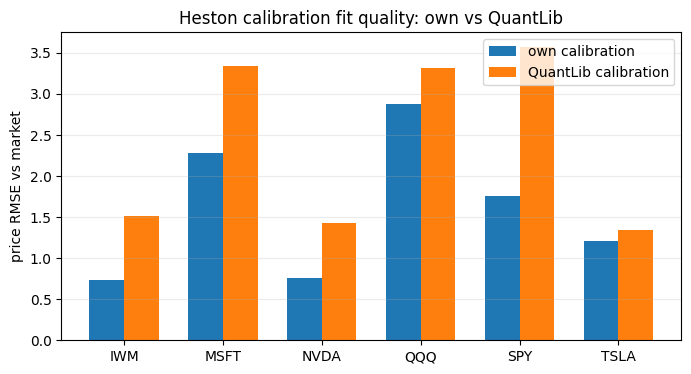

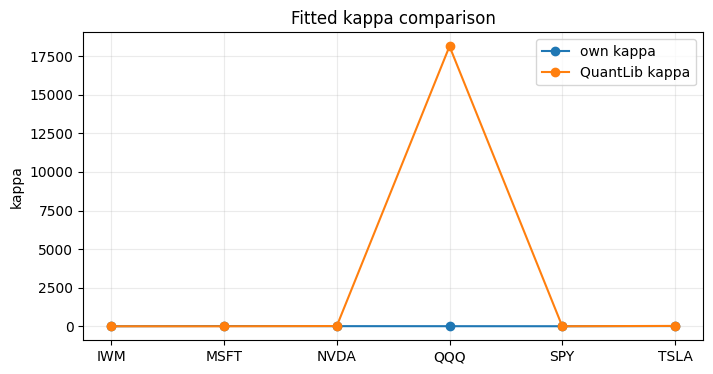

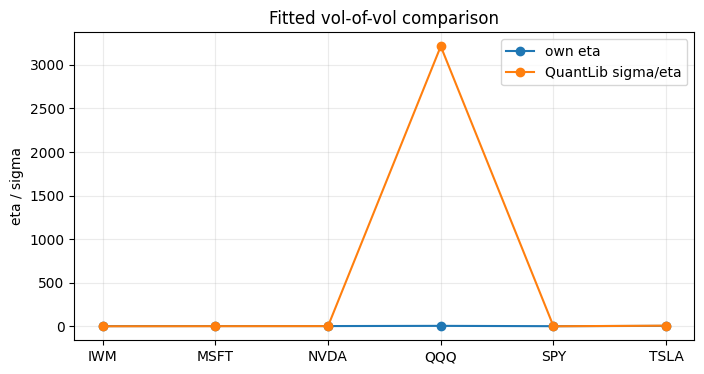

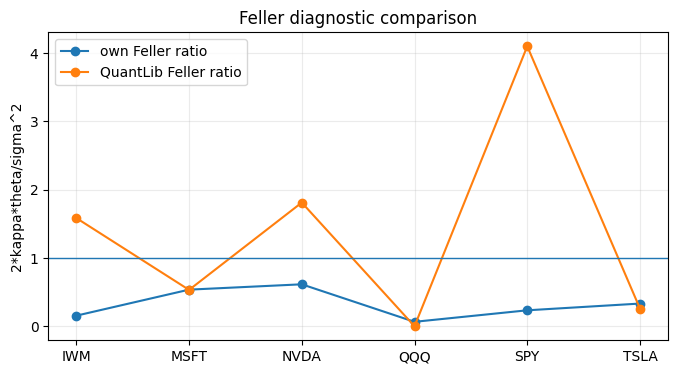

In [12]:
ok = calibration_comparison[calibration_comparison["status"].eq("ok")].copy()

if not ok.empty:
    plt.figure(figsize=(8, 4))
    x = np.arange(len(ok))
    width = 0.35
    plt.bar(x - width / 2, ok["own_market_rmse"], width, label="own calibration")
    plt.bar(x + width / 2, ok["ql_market_rmse"], width, label="QuantLib calibration")
    plt.xticks(x, ok["underlying"])
    plt.ylabel("price RMSE vs market")
    plt.title("Heston calibration fit quality: own vs QuantLib")
    plt.legend()
    plt.grid(True, alpha=0.25, axis="y")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(ok["underlying"], ok["own_kappa"], marker="o", label="own kappa")
    plt.plot(ok["underlying"], ok["ql_kappa"], marker="o", label="QuantLib kappa")
    plt.ylabel("kappa")
    plt.title("Fitted kappa comparison")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(ok["underlying"], ok["own_eta"], marker="o", label="own eta")
    plt.plot(ok["underlying"], ok["ql_eta"], marker="o", label="QuantLib sigma/eta")
    plt.ylabel("eta / sigma")
    plt.title("Fitted vol-of-vol comparison")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(ok["underlying"], ok["own_feller_ratio"], marker="o", label="own Feller ratio")
    plt.plot(ok["underlying"], ok["ql_feller_ratio"], marker="o", label="QuantLib Feller ratio")
    plt.axhline(1.0, linewidth=1)
    plt.ylabel("2*kappa*theta/sigma^2")
    plt.title("Feller diagnostic comparison")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.show()


## Where do the two calibrated surfaces differ most?

This is not an implementation check. It shows where the two optimizers/objectives choose different compromises.


In [13]:
def calibrated_surface_difference_detail(underlying: str) -> pd.DataFrame:
    item = prepared_by_underlying[underlying]
    quote_set = item["quote_set"]
    prepared = item["prepared"].reset_index(drop=True)
    own_fit = own_fits[underlying]
    ql_result = ql_fits[underlying]

    own_prices = price_with_library(quote_set, own_fit.best_params)
    ql_prices = ql_price_with_params(quote_set, ql_result["params"], item["loaded"]["market_data"])

    detail = prepared.copy()
    detail["own_model_price"] = own_prices
    detail["ql_calibrated_price"] = ql_prices
    detail["own_minus_market"] = own_prices - quote_set.mid
    detail["ql_minus_market"] = ql_prices - quote_set.mid
    detail["own_minus_ql_calibrated"] = own_prices - ql_prices
    detail["abs_own_minus_ql_calibrated"] = np.abs(detail["own_minus_ql_calibrated"])
    return detail.sort_values("abs_own_minus_ql_calibrated", ascending=False)


if QUANTLIB_AVAILABLE and not ok.empty:
    for underlying in ok.sort_values("own_vs_ql_calibrated_price_rmse", ascending=False)["underlying"].head(3):
        print(f"\nLargest calibrated-surface differences for {underlying}")
        detail = calibrated_surface_difference_detail(underlying)
        cols = [
            "contract_symbol", "expiry_days", "strike", "right", "mid",
            "own_model_price", "ql_calibrated_price",
            "own_minus_market", "ql_minus_market", "own_minus_ql_calibrated",
            "log_moneyness", "iv", "vega", "relative_spread",
        ]
        display(detail[[c for c in cols if c in detail.columns]].head(12))
else:
    print("Skipping calibrated-surface detail.")



Largest calibrated-surface differences for SPY


,contract_symbol,expiry_days,strike,right,mid,own_model_price,ql_calibrated_price,own_minus_market,ql_minus_market,own_minus_ql_calibrated,log_moneyness,iv,vega,relative_spread
390,SPY261130P00650000,176.534696,650.0,put,12.675,12.749858,6.643955,0.074858,-6.031045,6.105903,-0.143992,0.2497,1.301,0.007101
207,SPY261130C00650000,176.534696,650.0,call,110.485,111.666407,105.560504,1.181407,-4.924496,6.105903,-0.143992,0.2055,1.0896,0.004616
493,SPY261130P00645000,176.534696,645.0,put,12.23,12.136718,6.031762,-0.093282,-6.198238,6.104956,-0.151714,0.2544,1.2646,0.008177
323,SPY261130P00660000,176.534696,660.0,put,14.285,14.071179,8.023985,-0.213821,-6.261015,6.047193,-0.128724,0.2451,1.3932,0.0063
646,SPY261130P00630000,176.534696,630.0,put,10.515,10.467149,4.471142,-0.047851,-6.043858,5.996006,-0.175244,0.2641,1.1427,0.010461
576,SPY261130P00665000,176.534696,665.0,put,14.98,14.783191,8.797976,-0.196809,-6.182024,5.985214,-0.121177,0.2416,1.4352,0.009346
486,SPY261130P00625000,176.534696,625.0,put,9.89,9.962289,4.033622,0.072289,-5.856378,5.928667,-0.183213,0.2664,1.0993,0.008089
817,SPY261120P00650000,166.534696,650.0,put,12.1,12.052438,6.160531,-0.047562,-5.939469,5.891907,-0.142980,0.251,1.2507,0.013223
241,SPY261120P00645000,166.534696,645.0,put,11.51,11.458074,5.572771,-0.051926,-5.937229,5.885303,-0.150702,0.2545,1.2097,0.005213
577,SPY261120C00645000,166.534696,645.0,call,112.245,114.644560,108.759257,2.399560,-3.485743,5.885303,-0.150702,0.1946,0.9019,0.009355



Largest calibrated-surface differences for MSFT


,contract_symbol,expiry_days,strike,right,mid,own_model_price,ql_calibrated_price,own_minus_market,ql_minus_market,own_minus_ql_calibrated,log_moneyness,iv,vega,relative_spread
502,MSFT261120C00340000,166.533717,340.0,call,92.43,93.620804,98.399113,1.190804,5.969113,-4.778309,-0.228015,0.4231,0.7575,0.022287
557,MSFT261120P00340000,166.533717,340.0,put,9.14,7.984363,12.762672,-1.155637,3.622672,-4.778309,-0.228015,0.3522,0.6743,0.041575
558,MSFT261120P00345000,166.533717,345.0,put,10.07,8.943564,13.713460,-1.126436,3.643460,-4.769896,-0.213416,0.3493,0.7116,0.047666
499,MSFT261120C00345000,166.533717,345.0,call,87.515,89.663776,94.433672,2.148776,6.918672,-4.769896,-0.213416,0.4052,0.7753,0.014969
560,MSFT261120P00335000,166.533717,335.0,put,8.17,7.108301,11.867818,-1.061699,3.697818,-4.759517,-0.242830,0.3535,0.6343,0.083231
496,MSFT261120C00335000,166.533717,335.0,call,96.485,97.660970,102.420487,1.175970,5.935487,-4.759517,-0.242830,0.4295,0.7292,0.00653
570,MSFT261120P00350000,166.533717,350.0,put,11.13,9.990371,14.723169,-1.139629,3.593169,-4.732798,-0.199028,0.3471,0.7497,0.048518
511,MSFT261120C00350000,166.533717,350.0,call,83.73,85.794354,90.527152,2.064354,6.797152,-4.732798,-0.199028,0.4015,0.8064,0.042518
559,MSFT261120P00330000,166.533717,330.0,put,7.465,6.310770,11.026046,-1.154230,3.561046,-4.715276,-0.257868,0.3579,0.5995,0.070998
500,MSFT261120C00330000,166.533717,330.0,call,101.29,101.779669,106.494944,0.489669,5.204944,-4.715276,-0.257868,0.4458,0.7111,0.019943



Largest calibrated-surface differences for QQQ


,contract_symbol,expiry_days,strike,right,mid,own_model_price,ql_calibrated_price,own_minus_market,ql_minus_market,own_minus_ql_calibrated,log_moneyness,iv,vega,relative_spread
9,QQQ261016P00835000,131.534379,835.0,put,130.7695,129.888864,124.781326,-0.880636,-5.988174,5.107537,0.162863,0.2394,0.9603,0.001078
526,QQQ260918P00815000,103.534379,815.0,put,111.115,112.025494,106.919529,0.910494,-4.195471,5.105965,0.141428,0.219,0.7698,0.033569
350,QQQ260930P00820000,115.534379,820.0,put,113.38,116.456669,111.354385,3.076669,-2.025615,5.102284,0.146340,0.1893,0.6622,0.024872
563,QQQ260918C00810000,103.534379,810.0,call,5.945,6.094780,0.993435,0.149780,-4.951565,5.101346,0.135274,0.2259,0.8501,0.035324
321,QQQ260918P00810000,103.534379,810.0,put,107.355,107.482433,102.381087,0.127433,-4.973913,5.101346,0.135274,0.2269,0.8546,0.023194
352,QQQ261016P00840000,131.534379,840.0,put,137.09,134.471755,129.376146,-2.618245,-7.713854,5.095609,0.168833,0.2594,1.0159,0.024947
327,QQQ260821P00790000,75.534379,790.0,put,85.85,89.367687,84.303974,3.517687,-1.546026,5.063713,0.113082,0.1749,0.495,0.023529
209,QQQ261016P00830000,131.534379,830.0,put,127.0,125.336248,120.288261,-1.663752,-6.711739,5.047987,0.156857,0.2451,1.0302,0.017638
654,QQQ260930P00830000,115.534379,830.0,put,125.235,125.603995,120.564621,0.368995,-4.670379,5.039374,0.158462,0.2281,0.7971,0.040484
171,QQQ261016P00845000,131.534379,845.0,put,138.16,139.081884,134.061982,0.921884,-4.098018,5.019902,0.174767,0.2223,0.7797,0.015489


## Interpretation helper

This prints a short qualitative summary.

Use it to decide whether QuantLib calibration supports the earlier model-risk interpretation.


In [14]:
def interpret_calibration_comparison(table: pd.DataFrame) -> str:
    if table.empty:
        return "No calibration comparison rows were produced."
    if not QUANTLIB_AVAILABLE:
        return "QuantLib is not installed, so calibration comparison did not run."

    ok = table[table["status"].eq("ok")].copy()
    if ok.empty:
        return "No successful QuantLib calibration comparison rows were produced."

    lines = [
        "QuantLib calibration comparison summary:",
        f"- successful rows: {len(ok)} / {len(table)}",
        f"- median QuantLib/own market RMSE ratio: {ok['ql_rmse_ratio_to_own'].median(skipna=True):.4g}",
        f"- max QuantLib/own market RMSE ratio: {ok['ql_rmse_ratio_to_own'].max(skipna=True):.4g}",
        f"- max own-vs-QuantLib calibrated surface RMSE: {ok['own_vs_ql_calibrated_price_rmse'].max(skipna=True):.4g}",
        "",
        "Stress-pattern checks:",
    ]

    for _, row in ok.iterrows():
        flags = []
        if pd.notna(row.get("ql_eta")) and float(row["ql_eta"]) >= 3.0:
            flags.append("QL high eta/sigma")
        if pd.notna(row.get("ql_feller_ratio")) and float(row["ql_feller_ratio"]) < 1.0:
            flags.append("QL weak Feller")
        if pd.notna(row.get("ql_kappa")) and float(row["ql_kappa"]) >= 15.0:
            flags.append("QL high kappa")
        if not flags:
            flags.append("no major QL parameter stress")
        lines.append(
            f"- {row['underlying']}: own RMSE={row['own_market_rmse']:.4g}, "
            f"QL RMSE={row['ql_market_rmse']:.4g}, "
            f"own eta={row['own_eta']:.4g}, QL eta={row['ql_eta']:.4g}, "
            f"own Feller={row['own_feller_ratio']:.4g}, QL Feller={row['ql_feller_ratio']:.4g}; "
            + ", ".join(flags)
        )

    lines.append("")
    lines.append(
        "Interpretation: parameter equality is not expected because QuantLib and this library "
        "calibrate with different objectives/helpers. The useful signal is whether QuantLib "
        "achieves comparable residuals and/or shows similar stress patterns."
    )

    return "\n".join(lines)


print(interpret_calibration_comparison(calibration_comparison))


QuantLib calibration comparison summary:
- successful rows: 6 / 6
- median QuantLib/own market RMSE ratio: 1.666
- max QuantLib/own market RMSE ratio: 2.05
- max own-vs-QuantLib calibrated surface RMSE: 3.219

Stress-pattern checks:
- IWM: own RMSE=0.7366, QL RMSE=1.51, own eta=1.926, QL eta=0.383, own Feller=0.1557, QL Feller=1.585; no major QL parameter stress
- MSFT: own RMSE=2.279, QL RMSE=3.334, own eta=2.846, QL eta=1.267, own Feller=0.5368, QL Feller=0.5332; QL weak Feller
- NVDA: own RMSE=0.7617, QL RMSE=1.424, own eta=2.655, QL eta=1.986, own Feller=0.615, QL Feller=1.812; QL high kappa
- QQQ: own RMSE=2.873, QL RMSE=3.317, own eta=5, QL eta=3213, own Feller=0.06561, QL Feller=0.0003346; QL high eta/sigma, QL weak Feller, QL high kappa
- SPY: own RMSE=1.756, QL RMSE=3.572, own eta=1.284, QL eta=0.2055, own Feller=0.2343, QL Feller=4.101; no major QL parameter stress
- TSLA: own RMSE=1.21, QL RMSE=1.347, own eta=5, QL eta=7.185, own Feller=0.333, QL Feller=0.2596; QL high eta/s